In [1]:
from script.model.pepbridge import PepBridge
from script.model.lora import build_model_with_lora,\
    inject_lora_into_trunk_last_n,freeze_module_except_lora
from script.dataset import PTDataSet, MPDataSet, MPTDataSet, MPTGenDataSet,\
    build_loader_for_long_tail, build_loader_uniform_by_peptide
from script.dataprocess import mk_aa_dict, mk_bv_dict
from script.utils import model_fn, encoder_load_state_dict, df_train_test_split, setup_logger,\
    read_csv_with_index_allow_duplicate_names
from script.train import train_three_phases_multi_loaders, generator_train,_mrf_energy
from script.generate_function import batch_mrf_sample_and_decode

import pandas as pd 
import numpy as np
import os

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import pickle

from script.model.generator import PepBridgeGenerator,Discriminator



/Users/aapupu/Desktop/vscode/TCR/code/script/loss.py:157: SyntaxWarning: invalid escape sequence '\l'
  """


In [2]:
aa_dict = mk_aa_dict()
bv_dict = mk_bv_dict()

In [3]:
generator = PepBridgeGenerator( aa_size=len(aa_dict),
        max_len_dict={"mhc":34, "peptide":15, "cdr3":20},
        d_seq=128, d_head_seq=32,
        d_pair=64, d_head_pair=32,
        dropout=0.1,
        n_layers_dict={"mhc":3, "peptide":6, "cdr3":6,
                        "mp":3, "pt":3, "mpt":1, 
                        'gen':12},
        trbv_size=len(bv_dict), film=True, lora=True)

In [4]:
pepbridge_pama = torch.load('./doc/pepbridge_test.pt', map_location='cpu')
state_dict = pepbridge_pama['model_state']

# 要忽略的两个参数
keys_to_drop = [
    "mp_contact_pred_head.mlp.3.weight",
    "mp_contact_pred_head.mlp.3.bias",
]

for k in keys_to_drop:
    if k in state_dict:
        print(f"Drop key from checkpoint: {k}")
        state_dict.pop(k)

# 再加载，strict=False 允许这两个参数保持为当前模型初始化值
msg = generator.pepbridge.load_state_dict(state_dict, strict=False)
print("Missing keys:", msg.missing_keys)
print("Unexpected keys:", msg.unexpected_keys)

Drop key from checkpoint: mp_contact_pred_head.mlp.3.weight
Drop key from checkpoint: mp_contact_pred_head.mlp.3.bias
Missing keys: ['mp_contact_pred_head.mlp.3.weight', 'mp_contact_pred_head.mlp.3.bias']
Unexpected keys: []


In [5]:
use_lora = True
finetune_trunk = False

In [6]:
for p in generator.pepbridge.parameters():
    p.requires_grad = False

if use_lora:
    inject_lora_into_trunk_last_n(
        generator.pepbridge.mpt_pair_aware_trunk,
        last_n=1,
        cfg_seq_pair=((8, 16), (4, 8)),
        dropout=0.1,
        freeze_base=False, 
    )
    freeze_module_except_lora(generator.pepbridge.mpt_pair_aware_trunk)
    print("[configure_pepbridge] mode = LoRA, only LoRA in mpt trunk is trainable")
else:
    if finetune_trunk:
        for p in generator.pepbridge.mpt_pair_aware_trunk.parameters():
            p.requires_grad = True
        # for p in generator.pepbridge.mpt_joint_embedder.parameters():
        #     p.requires_grad = True
        print("[configure_pepbridge] mode = mpt joint embedder and trunk are trainable (no LoRA)")
    else:
        print("[configure_pepbridge] mode = all frozen (pepbridge as frozen encoder)")

[configure_pepbridge] mode = LoRA, only LoRA in mpt trunk is trainable


In [7]:
discriminator = Discriminator(aa_size=len(aa_dict),bv_size=len(bv_dict),
                              d_emb=64, d_hidden=128, dropout=0.1, tau=0.5)

In [8]:
total_params = sum(p.numel() for p in generator.parameters())
print("Generator total params:", total_params)
total_params = sum(p.numel() for p in discriminator.parameters())
print("Discriminator total params:", total_params)

Generator total params: 13116528
Discriminator total params: 54049


In [9]:
gen_train = pd.read_csv('../pMHC_TCR/dataset/gen_train.csv',index_col=0,header=0)
gen_test1 = pd.read_csv('../pMHC_TCR/dataset/gen_test_hard.csv',index_col=0,header=0)
gen_test2 = pd.read_csv('../pMHC_TCR/dataset/gen_test_random.csv',index_col=0,header=0)

In [10]:
gen_train, gen_val = df_train_test_split(gen_train,val_split=0.01,seed=42)

In [11]:
def weighted_sampler(df, column, replacement, alpha=1):
    lengths = np.array(df[column])
    group_ids = lengths.copy()

    unique_groups, counts = np.unique(group_ids, return_counts=True)
    inv = 1.0 / np.power(counts.astype(np.float32), alpha)
    group_weights_arr = inv / inv.sum()
    group_weights = {g: w for g, w in zip(unique_groups, group_weights_arr)}
    # group_weights = {g: 1.0 / c for g, c in zip(unique_groups, counts)}
    
    sample_weights = np.array([group_weights[g] for g in group_ids], dtype=np.float32)
    sample_weights_t = torch.from_numpy(sample_weights) 
    sampler = WeightedRandomSampler(
        weights=sample_weights_t,
        num_samples=len(sample_weights_t), 
        replacement=replacement                   
    )
    return sampler

In [19]:
train_sampler = weighted_sampler(df=gen_train, column='peptide', replacement=True, alpha=0.5)
val_sampler = weighted_sampler(df=gen_val, column='peptide', replacement=False, alpha=0.5)

gen_train_loader = DataLoader(
    MPTGenDataSet(mpt_df=gen_train, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=True, pos=True, real=True,
               distillation=False,
               pep_mask=None, cdr3_mask=0.5),
                batch_size=8, shuffle=False,sampler=train_sampler)

gen_test_loader = DataLoader(
    MPTGenDataSet(mpt_df=gen_test1[:10], mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=True, pos=True, real=True,
               distillation=False,
               pep_mask=None, cdr3_mask=None),
                batch_size=2, shuffle=False, sampler=None,
                drop_last=False)

gen_val_loader = build_loader_uniform_by_peptide(   
        MPTGenDataSet(mpt_df=gen_val, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=True, pos=True, real=True,
               distillation=False,
               pep_mask=None, cdr3_mask=None),
        peptide_ids = gen_val.peptide, 
        peptides_per_step=8, 
        samples_per_peptide=1, 
        seed=42,
        num_workers=0, pin_memory=False,
        ensure_full_batch=False)

In [12]:
logger = setup_logger()

In [ ]:
generator_train(
    generator=generator,
    discriminator=discriminator,
    loader=gen_train_loader,  
    device = "cpu",
    save_dir= "./checkpoints_pepbridge_gen",
    epochs = 100,
    steps_per_epoch = 10, 
    optimizer_ctor=lambda params: torch.optim.AdamW(params, lr=2e-4, weight_decay=0.01),
    grad_accum_steps= 1,
    amp = False,
    log_interval = 5,
    val_loader = gen_val_loader,
    eval_every_epochs= 1,
    val_max_steps=10,
    logger = logger,
    distillation = False,
    lambda_bv = 0.2,
    lambda_adv = 0.1,
    lambda_margin = 1.0)

In [13]:
generator_dict = torch.load('./checkpoints_pepbridge_gen/generator.pt', map_location='cpu')
msg = generator.load_state_dict(generator_dict, strict=False)
msg

<All keys matched successfully>

In [20]:
generator.eval()
seq_list, pair_list, bv_list, e_list = [], [], [], []
seq_mask_list, pair_mask_list = [], []
with torch.no_grad():
    for out, idx in gen_test_loader:
        mhc_v      = out["mhc"]
        esm_mhc_v  = out.get("esm_mhc", None)
        if esm_mhc_v is not None:
            esm_mhc_v = esm_mhc_v
        peptide_v  = out["peptide"]
        neg_cdr3_v = out["neg_cdr3"]
        pos_bv_v   = out["pos_bv"]
        pos_cdr3_v = out["pos_cdr3"]
        cdr3_mask_v = (neg_cdr3_v != 0)
        pair_mask_v = cdr3_mask_v.unsqueeze(2) & cdr3_mask_v.unsqueeze(1)
        seq_logits_v, pair_logits_v, bv_logits_v = generator(
                            mhc_v, peptide_v, neg_cdr3_v, esm_mhc_v
                        )
        
        E = _mrf_energy(
                    seq_logits=seq_logits_v,
                    pair_logits=pair_logits_v,
                    labels=pos_cdr3_v,
                    mask=cdr3_mask_v,
                        )
        seq_list.append(seq_logits_v)
        pair_list.append(pair_logits_v)
        bv_list.append(bv_logits_v)
        e_list.append(E)
        seq_mask_list.append(cdr3_mask_v)
        pair_mask_list.append(pair_mask_v)

In [21]:
gen_test1[:10]

,peptide,MHC,bv_pos,cdr3_pos,cdr3_neg,fuzz_score,bv_real,cdr3_real
0,GILGFVFTL,HLA-A02:01,TRBV19,CASSLISYNEQF,CASSLDQGTQYF,58,TRBV29-1,CSVPGQGLEQYF
1,GILGFVFTL,HLA-A02:01,TRBV19,CASSLISYNEQF,CASSRDSHVLTF,50,TRBV5-1,CASTAATDTQYF
2,GILGFVFTL,HLA-A02:01,TRBV19,CASSLISYNEQF,CASSLGLQKLFF,58,TRBV2,CASRSIDQPQHF
3,GILGFVFTL,HLA-A02:01,TRBV19,CASSLISYNEQF,CASSPNLLGYTF,58,TRBV29-1,CSVEEGAYEQYF
4,GILGFVFTL,HLA-A02:01,TRBV19,CASSLISYNEQF,CASSQPTGKAYF,50,TRBV4-1,CASREGTDKQYF
5,GLCTLVAML,HLA-A02:01,TRBV20-1,CASARDWTGNGYTF,CASAQADLSNGYTF,71,TRBV6-1,CASSRTSQADTQYF
6,GLCTLVAML,HLA-A02:01,TRBV20-1,CASARDWTGNGYTF,CASAIAGRPNGYTF,71,TRBV11-2,CASSLVLLKNEQFF
7,GLCTLVAML,HLA-A02:01,TRBV20-1,CASARDWTGNGYTF,CASAKGVGSNGYTF,71,TRBV6-5,CASSYTLRADTIYF
8,GLCTLVAML,HLA-A02:01,TRBV20-1,CASARDWTGNGYTF,CASAGGQGINGYTF,71,TRBV12-3,CASITLAEGETQYF
9,GLCTLVAML,HLA-A02:01,TRBV20-1,CASARDWTGNGYTF,CASATPGQRNGYTF,71,TRBV6-5,CASRLLDTPYEQYF


In [23]:
batch_mrf_sample_and_decode(
    bv_logits_batch=torch.cat(bv_list, dim=0),   # [B, BvC]
    seq_logits_batch=torch.cat(seq_list, dim=0),  # [B, N, C]
    pair_logits_batch=torch.cat(pair_list, dim=0), # [B, N, N, C, C] 或 [B, N, N, C*C]
    seq_mask_batch=torch.cat(seq_mask_list, dim=0),    # [B, N] 
    pair_mask_batch=torch.cat(pair_mask_list, dim=0),   # [B, N, N]
    T = 1,
    steps = 5,
    n_samples = 20,
    forbid_indices=(0, 21, 22, 23, 24, 25),
    amino_acid_dict=aa_dict,
    bv_dict=bv_dict
)

{0: [('TRBV13', 'CASSTDRGTQYF'),
  ('TRBV19', 'CASSLAADTQYF'),
  ('TRBV19', 'CASSQLLVTQYF'),
  ('TRBV19', 'CASSGYAGEQYY'),
  ('TRBV19', 'CASSLNGGTQYF'),
  ('TRBV19', 'CSSSLQFGTQYF'),
  ('TRBV27', 'CASSLDSGEQYF'),
  ('TRBV19', 'CASSLGSETQYF'),
  ('TRBV7-9', 'CASSLLQETQYF'),
  ('TRBV19', 'CASSLLQGTQYF'),
  ('TRBV24-1', 'CASSIDGEEQYF'),
  ('TRBV19', 'CASSMGVYEQYF'),
  ('TRBV19', 'CASSLFQETQYF'),
  ('TRBV3-1', 'CASSLGQETQYF'),
  ('TRBV19', 'CASSMRQGTQYF'),
  ('TRBV19', 'CASSLIQGTQYF'),
  ('TRBV19', 'CASSLVVGTQYF'),
  ('TRBV19', 'CASSLYQETQYF'),
  ('TRBV19', 'CASSLRSETQYF'),
  ('TRBV19', 'CASSLGTETQYF')],
 1: [('TRBV19', 'CASSLSKNVLTF'),
  ('TRBV11-1', 'CASSIALNVLTF'),
  ('TRBV19', 'CASSLDGNVLTF'),
  ('TRBV19', 'CASSQVTNVLTY'),
  ('TRBV19', 'CASSQGANVLTF'),
  ('TRBV6-2', 'CASSYLANVLTF'),
  ('TRBV19', 'CASSRDSNVLTF'),
  ('TRBV19', 'CASSVAGNVLTF'),
  ('TRBV19', 'CSASRDLMVLTF'),
  ('TRBV19', 'CASSLGGNVLTF'),
  ('TRBV19', 'CASSQDGNVLTF'),
  ('TRBV10-1', 'CASSQDVNVLTF'),
  ('TRBV19', 'CASSPNSNVL

In [20]:
e_list

[tensor([-31.1121, -24.5968]),
 tensor([-29.6081, -29.4384]),
 tensor([-28.9498, -33.0020]),
 tensor([-32.0523, -32.3884]),
 tensor([-32.7738, -31.2641])]

In [ ]:
os.chdir('./data/mp/')

In [ ]:
mp_train = pd.read_csv('../../../pMHC/mp_train.csv', index_col=0, header=0)

In [ ]:
file_list = os.listdir('.')
mp_dist_dict = {}
for i in file_list:
    file_i = read_csv_with_index_allow_duplicate_names(i)
    mp_dist_dict[i] = file_i.to_numpy(dtype=float).flatten()

In [ ]:
all_mp_dist = np.concatenate(list(mp_dist_dict.values()))
print("min / max:", all_mp_dist.min(), all_mp_dist.max())
for q in [0.05, 0.25, 0.5, 0.75, 0.95]:
    print(f"quantile {q}: {np.quantile(all_mp_dist, q):.3f}")

min / max: 2.0987045764923096 108.84343719482422
quantile 0.05: 3.357
quantile 0.25: 6.429
quantile 0.5: 9.562
quantile 0.75: 13.883
quantile 0.95: 20.714


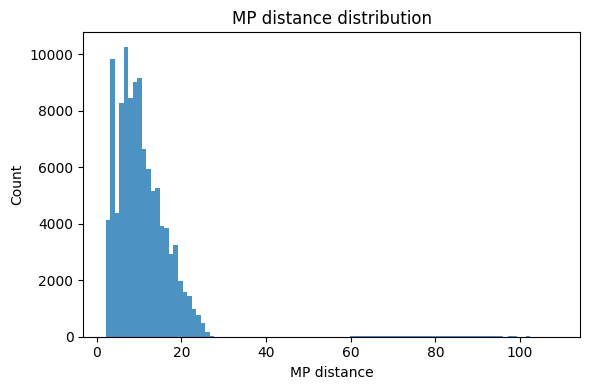

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(all_mp_dist, bins=100, alpha=0.8)
plt.xlabel("MP distance")
plt.ylabel("Count")
plt.title("MP distance distribution")
plt.tight_layout()
plt.show()

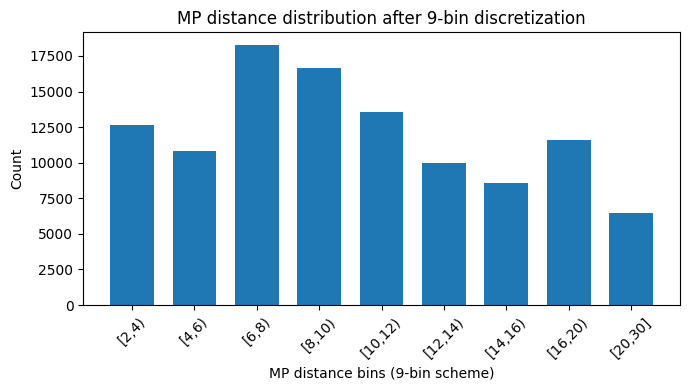

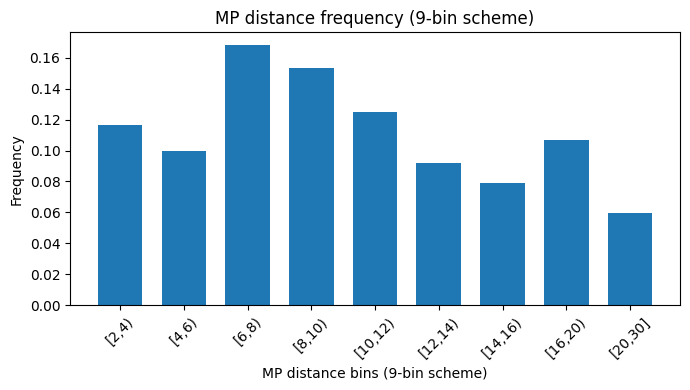

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. 原始距离做一个 clip，和我们设计 bin 时保持一致 =====
dist_clip = np.clip(all_mp_dist, 2.0, 30.0)   # [N]

# ===== 2. 9-bin 方案：边界 & center =====
# 区间：
# 1: [2, 4)
# 2: [4, 6)
# 3: [6, 8)
# 4: [8, 10)
# 5: [10, 12)
# 6: [12, 14)
# 7: [14, 16)
# 8: [16, 22)
# 9: [22, 30]  (以及原来 >30 都被 clip 到 30 进这一档)

bin_edges = np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 20.0, 30.0])
bin_centers = np.array([3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0, 18.0, 25.0])

# ===== 3. 统计每个 bin 里的样本数 =====
# np.digitize 返回的是 bin 索引（从 1 开始），这里转成 0~8
bin_idx = np.digitize(dist_clip, bin_edges, right=False) - 1   # [N], 每个值在 0~8
bin_idx = np.clip(bin_idx, 0, len(bin_centers)-1)              # 保险起见再 clip 一下

counts = np.bincount(bin_idx, minlength=len(bin_centers))      # [9]

# ===== 4. 画“转换后的分布图”：每个 bin 的计数 =====
plt.figure(figsize=(7,4))
x = np.arange(len(bin_centers))

# 方式 A：用区间作为 x 轴标签
labels = [
    "[2,4)", "[4,6)", "[6,8)", "[8,10)",
    "[10,12)", "[12,14)", "[14,16)", "[16,20)", "[20,30]"
]

plt.bar(x, counts, width=0.7)
plt.xticks(x, labels, rotation=45)
plt.xlabel("MP distance bins (9-bin scheme)")
plt.ylabel("Count")
plt.title("MP distance distribution after 9-bin discretization")
plt.tight_layout()
plt.show()

# 如果想看“概率分布”而不是绝对数量，也可以：
plt.figure(figsize=(7,4))
probs = counts / counts.sum()
plt.bar(x, probs, width=0.7)
plt.xticks(x, labels, rotation=45)
plt.xlabel("MP distance bins (9-bin scheme)")
plt.ylabel("Frequency")
plt.title("MP distance frequency (9-bin scheme)")
plt.tight_layout()
plt.show()

In [ ]:
with open('./doc/esm_emb_HLAI.pkl', 'rb') as f:
    mhc_dict = pickle.load(f)

In [ ]:
mp_test = pd.read_csv('../pMHC/External_mp_test.csv',index_col=0,header=0)

In [ ]:
np.asarray(mp_test['len'])

array([ 8,  8,  8, ..., 14, 14, 14])

0          8
1          8
2          8
3          8
4          8
          ..
103860    14
103861    14
103862    14
103863    14
103864    14
Name: len, Length: 102459, dtype: int64

In [ ]:
mp_train = pd.read_csv('../pMHC/mp_train.csv',index_col=0,header=0)
mp_train

,MHC,peptide,binding,len
0,HLA-C14:02,YFPLAPFNQL,1,10
1,HLA-B44:02,KESKINQVF,1,9
2,HLA-B54:01,QPHDPLVPLSA,1,11
3,HLA-B57:03,RTIADSLINSF,1,11
4,HLA-C08:02,LLDELPQSVL,1,10
...,...,...,...,...
1487169,HLA-C17:01,QITQRKWE,0,8
1487170,HLA-C17:01,FTAVVLVSAD,0,10
1487171,HLA-C17:01,GWEVKSLR,0,8
1487172,HLA-C17:01,TADSIGRVKA,0,10


In [ ]:
row = mp_test.iloc[1]

In [ ]:
row['MHC']

'HLA-A01:01'

In [ ]:
mp_train.columns

Index(['MHC', 'peptide', 'binding', 'len'], dtype='object')

In [ ]:
aa_dict = mk_aa_dict()
bv_dcit = mk_bv_dict()

device = 'mps'

model = model_fn(aa_vocab_size=len(aa_dict),
                trbv_vocab_size=len(bv_dcit))
model.to(device)
model = encoder_load_state_dict(model, peptide_pt_path='./doc/peptide_mlm.pt',
                                cdr3_pt_path='./doc/cdr3_mlm.pt', device=device)

In [ ]:
pt_df = pd.read_csv('/Users/aapupu/Desktop/vscode/TCR/pMHC_TCR/dataset/pt_train.csv', 
                    header=0, index_col=0)
pt_train, pt_val = df_train_test_split(pt_df, val_split=0.2, seed=42)
del pt_df

mp_df = pd.read_csv('/Users/aapupu/Desktop/vscode/TCR/pMHC/mp_train.csv', 
                    header=0, index_col=0)
mp_train, mp_val = df_train_test_split(mp_df, val_split=0.2, seed=42)
del mp_df

mpt_df = pd.read_csv('/Users/aapupu/Desktop/vscode/TCR/pMHC_TCR/dataset/mpt_train.csv', 
                    header=0, index_col=0)
mpt_train, mpt_val = df_train_test_split(mpt_df, val_split=0.2, seed=42)
del mpt_df

align_df = pd.read_csv('/Users/aapupu/Desktop/vscode/TCR/pMHC/random_pMHC_cdr3_train.csv', 
                    header=0, index_col=0,nrows=100000)
align_train, align_val = df_train_test_split(align_df, val_split=0.2, seed=42)
del align_df

In [ ]:
imm_df = pd.read_csv('/Users/aapupu/Desktop/vscode/TCR/immuno-genicity/immunogenicity_train.csv', 
                    header=0, index_col=0)
imm_train, imm_val = df_train_test_split(imm_df, val_split=0.2, seed=42)

mp_contact_df = pd.read_csv('./data/mp_pdb_train.csv',  header=0, index_col=0)
mp_contact_train, mp_contact_val = df_train_test_split(mp_contact_df, val_split=0.2, seed=42)

pt_contact_df = pd.read_csv('./data/pt_pdb_train.csv', header=0, index_col=0)
pt_contact_train, pt_contact_val = df_train_test_split(pt_contact_df, val_split=0.2, seed=42)

In [ ]:
mp_train_loader = DataLoader(MPDataSet(mp_df=mp_train, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=True, 
                        immunogenicity=False, contact=False, mask=None),
                        batch_size= 16, shuffle=True)

mp_val_loader = DataLoader(MPDataSet(mp_df=mp_val, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=True, 
                        immunogenicity=False, contact=False, mask=None),
                        batch_size= 16, shuffle=True)

imm_train_loader = DataLoader(MPDataSet(mp_df=imm_train, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=False, 
                        immunogenicity=True, contact=False, mask=None),
                        batch_size= 16, shuffle=True)

imm_val_loader = DataLoader(MPDataSet(mp_df=imm_val, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=False, 
                        immunogenicity=True, contact=False, mask=None),
                        batch_size= 16, shuffle=True)

mp_contact_train_loader = DataLoader(MPDataSet(mp_df=mp_contact_train, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=False, 
                        immunogenicity=False, contact=True, mask=None),
                        batch_size= 2, shuffle=True)

mp_contact_val_loader = DataLoader(MPDataSet(mp_df=mp_contact_val, mhc_type='HLAI', 
                       mhc_max_len=34, pep_max_len=15,
                        binding=False, 
                        immunogenicity=False, contact=True, mask=None),
                        batch_size= 2, shuffle=True)

In [ ]:
pt_train_loader = build_loader_for_long_tail(
    dataset=PTDataSet(pt_train, pep_max_len=15, cdr3_max_len=20,
                            binding=True, contact=False, 
                            pep_mask=None, cdr3_mask=0.5),
    peptide_ids = pt_train.peptide, t=1e-3,
    batch_size=16, max_per_group=2,
    alpha=0.5, mix=0.10, repeat_cap=64, seed=42,
    num_workers=0, pin_memory=False
)

pt_val_loader = build_loader_uniform_by_peptide(
    dataset=PTDataSet(pt_val, pep_max_len=15, 
                      cdr3_max_len=20,
                    binding=True, contact=False, 
                    pep_mask=None, cdr3_mask=None),
    peptide_ids = pt_val.peptide, 
    peptides_per_step=64, 
    samples_per_peptide=4, 
    seed=42,
    num_workers=0, pin_memory=False,
    ensure_full_batch=False
)



In [ ]:
mpt_train_loader =build_loader_for_long_tail(
    dataset=MPTDataSet(mpt_train, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=True, binding=True, 
               pep_mask=None, cdr3_mask=0.5),
    peptide_ids = mpt_train.peptide,t=1e-3,
    batch_size=16, max_per_group=2,
    alpha=0.5, mix=0.10, repeat_cap=64, seed=42,
    num_workers=0, pin_memory=False
)

mpt_val_loader = build_loader_uniform_by_peptide(
    dataset=MPTDataSet(mpt_val, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=True, binding=True, 
               pep_mask=None, cdr3_mask=None),
    peptide_ids = mpt_val.peptide, 
    peptides_per_step=64, 
    samples_per_peptide=4, 
    seed=42,
    num_workers=0, pin_memory=False,
    ensure_full_batch=False
)

In [ ]:
pt_contact_train_loader = DataLoader(PTDataSet(pt_contact_train, pep_max_len=15, cdr3_max_len=20,
                                binding=False, contact=True, 
                                pep_mask=None, cdr3_mask=None),
                                batch_size= 2, shuffle=True)

pt_contact_val_loader = DataLoader(PTDataSet(pt_contact_val, pep_max_len=15, cdr3_max_len=20,
                                binding=False, contact=True, 
                                pep_mask=None, cdr3_mask=None),
                                batch_size= 2, shuffle=True)

In [ ]:
align_train_loader = DataLoader(MPTDataSet(align_train, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=False, binding=False, 
               pep_mask=None, cdr3_mask=None),
               batch_size=16, shuffle=True)

align_val_loader = DataLoader(MPTDataSet(align_val, mhc_type='HLAI', 
               mhc_max_len=34, pep_max_len=15, cdr3_max_len=20,
               bv=False, binding=False, 
               pep_mask=None, cdr3_mask=None),
               batch_size=8, shuffle=True)

In [ ]:
train_loaders =dict(
    align=align_train_loader, mp=mp_train_loader,pt=pt_train_loader,
    mp_contact=mp_contact_train_loader, pt_contact=pt_contact_train_loader,
    imm=imm_train_loader, mpt=mpt_train_loader
)

val_loaders =dict(
    align=align_val_loader, mp=mp_val_loader,pt=pt_val_loader,
    mp_contact=mp_contact_val_loader, pt_contact=pt_contact_val_loader,
    imm=imm_val_loader, mpt=mpt_val_loader
)

In [ ]:
logger = setup_logger()
train_three_phases_multi_loaders(  
    model=model,
    loaders=train_loaders,
    device="mps",
    save_dir="./checkpoints_multi_lora_align_all",
    epochs_A=1, epochs_B=1, epochs_C=1,
    steps_per_epoch=1200, 
    optimizer_ctor=lambda params: torch.optim.AdamW(params, lr=5e-3, weight_decay=0.01),
    grad_accum_steps=1,
    amp=False,
    new_optimizer_each_phase=False,
    log_interval=10,
    task_every = {"mp_contact": 50, "pt_contact": 50},   #
    val_loaders= val_loaders,
    eval_every_epochs=1,
    pep_align=True,
    all_align=True,
    use_lora=True,
    last_n=2,
    cfg_seq_pair=((8,16),(4,8)),
    logger=logger)

[2025-11-14 16:41:06] [Phase A] epoch 1/1 step 10/1200 total=1.5028 | align=0.7804 MP=0.7134 PT=0.6468 contact=0.0000 IMM=0.0000 MPT=0.0000 logic_imm=0.0000 logic_mpt=0.0000
[2025-11-14 16:41:29] [Phase A] epoch 1/1 step 20/1200 total=1.4479 | align=0.5401 MP=0.6968 PT=0.6118 contact=0.0000 IMM=0.0000 MPT=0.0000 logic_imm=0.0000 logic_mpt=0.0000
[2025-11-14 16:41:51] [Phase A] epoch 1/1 step 30/1200 total=1.4216 | align=0.5012 MP=0.6875 PT=0.5966 contact=0.0000 IMM=0.0000 MPT=0.0000 logic_imm=0.0000 logic_mpt=0.0000
[2025-11-14 16:42:13] [Phase A] epoch 1/1 step 40/1200 total=1.4493 | align=0.4889 MP=0.6967 PT=0.6133 contact=0.0000 IMM=0.0000 MPT=0.0000 logic_imm=0.0000 logic_mpt=0.0000


KeyboardInterrupt: 